# Set 14 - NN2: CNN-Filter, Pooling und Feature Maps

**Ziel:** Die CNN-Bausteine aus der PDF (Seiten 4–6) an Ziffernbildern sichtbar machen. Erst wenden wir handgewählte Filter an, danach trainieren wir ein kleines CNN auf der CPU.

Faltungen betrachten lokale Nachbarschaften; derselbe Filter wird an vielen Bildpositionen angewendet. Pooling reduziert die räumliche Auflösung. Das kann die Empfindlichkeit gegenüber kleinen Verschiebungen vermindern, garantiert aber keine vollständige Positionsinvarianz.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
from torch import nn

kandidaten=[Path.cwd(),*Path.cwd().parents]
set_ordner=next((p for basis in kandidaten for p in (basis,basis/"set14-neuronale-netze-nn2")
                 if (p/"cv_tools.py").exists()),None)
if set_ordner is None:raise FileNotFoundError("Notebook innerhalb des Kursordners starten.")
if str(set_ordner) not in sys.path:sys.path.insert(0,str(set_ordner))
from cv_tools import (cpu_setup,ziffern_split,loader,trainiere,auswerten,lernkurven,
                      bildgalerie,KleinesCNN,FrozenMobileNet,backbone_hash,
                      mobilenet_bilder,extrahiere_features)
device=cpu_setup()
print("PyTorch:",torch.__version__,"Gerät:",device,"CUDA-Build:",torch.version.cuda)
assert torch.version.cuda is None

PyTorch: 2.14.1+cpu Gerät: cpu CUDA-Build: None


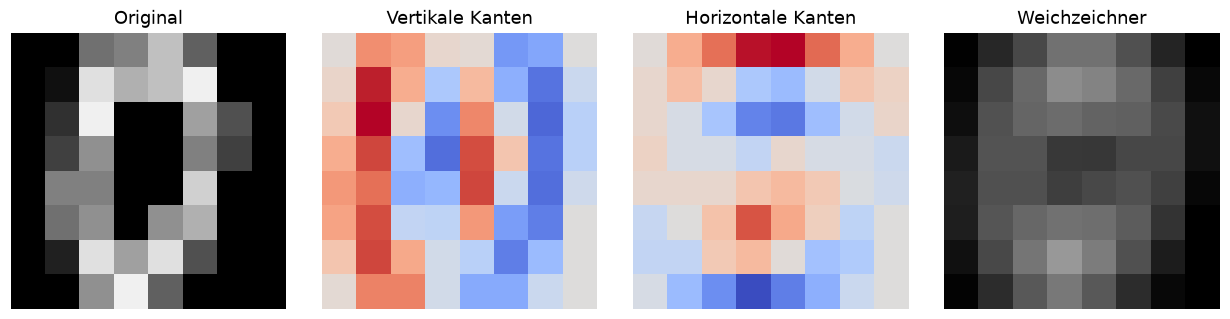

In [2]:
import torch.nn.functional as F
bilder,labels,split=ziffern_split()
bild=bilder[split["train"]][0:1]
filter_kernels=torch.tensor([
    [[-1,0,1],[-1,0,1],[-1,0,1]],
    [[-1,-1,-1],[0,0,0],[1,1,1]],
    [[1,1,1],[1,1,1],[1,1,1]],
],dtype=torch.float32).unsqueeze(1)
filter_kernels[2]/=9
gefiltert=F.conv2d(bild,filter_kernels,padding=1)
fig,axes=plt.subplots(1,4,figsize=(12,3))
axes[0].imshow(bild[0,0],cmap="gray",vmin=0,vmax=1);axes[0].set_title("Original")
for i,name in enumerate(["Vertikale Kanten","Horizontale Kanten","Weichzeichner"]):
    response=gefiltert[0,i].numpy()
    if i<2:
        grenze=max(float(np.abs(response).max()),0.01)
        axes[i+1].imshow(response,cmap="coolwarm",vmin=-grenze,vmax=grenze)
    else:axes[i+1].imshow(response,cmap="gray",vmin=0,vmax=1)
    axes[i+1].set_title(name)
for ax in axes:ax.axis("off")
plt.tight_layout();plt.show()

## 1. Was unterscheidet diese Filter von CNN-Filtern?

Hier wurden die Gewichte von uns fest vorgegeben. Im CNN werden sie aus der Klassifikations-Loss gelernt. Eine Feature Map enthält die Antwort eines Filters an den Bildpositionen. Positive und negative Antworten eines Kantenfilters haben Bedeutung; eine Grauabbildung allein könnte negative Werte verdecken.

PyTorch `Conv2d` berechnet technisch eine Kreuzkorrelation ohne Spiegelung des Kernels. Bei gelernten Gewichten verwendet man dafür in der Praxis trotzdem den Begriff Faltung.

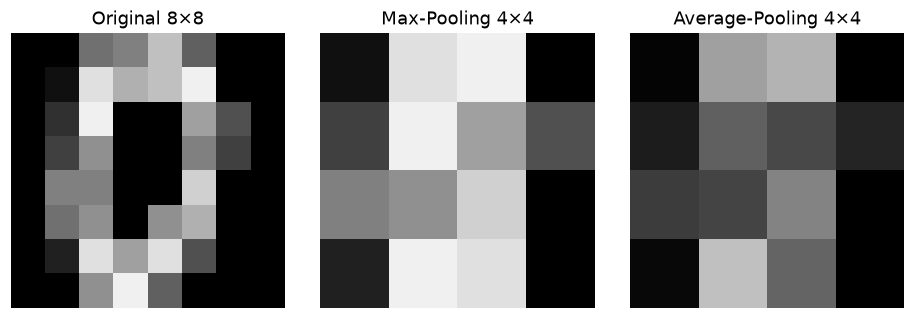

In [3]:
max_pool=F.max_pool2d(bild,kernel_size=2)
avg_pool=F.avg_pool2d(bild,kernel_size=2)
fig,axes=plt.subplots(1,3,figsize=(9,3))
for ax,im,name in zip(axes,[bild[0,0],max_pool[0,0],avg_pool[0,0]],["Original 8×8","Max-Pooling 4×4","Average-Pooling 4×4"]):
    ax.imshow(im,cmap="gray",vmin=0,vmax=1,interpolation="nearest");ax.set_title(name);ax.axis("off")
plt.tight_layout();plt.show()

## 2. Ein sehr kleines CNN

| Schritt | Form pro Bild |
|---|---|
| Eingabe | 1 × 8 × 8 |
| Conv 3×3, padding=1, ReLU | 8 × 8 × 8 |
| MaxPool 2×2 | 8 × 4 × 4 |
| Zweite Conv und ReLU | 16 × 4 × 4 |
| Zweites Pooling | 16 × 2 × 2 |
| Flatten + Linear | 10 Logits |

Die räumlichen Maße bleiben durch Padding bei einer Conv erhalten; Pooling halbiert sie. In PyTorch stehen die Kanäle vor Höhe und Breite.

In [4]:
train_loader=loader(bilder[split["train"]],labels[split["train"]],shuffle=True)
val_loader=loader(bilder[split["val"]],labels[split["val"]])
test_loader=loader(bilder[split["test"]],labels[split["test"]])
modell=KleinesCNN().to(device)
print(modell)
x=bilder[split["train"]][:2]
formen=[]
for layer in modell.features:
    x=layer(x);formen.append({"Schicht":type(layer).__name__,"Batchform":tuple(x.shape)})
display(pd.DataFrame(formen))
print("Parameter:",sum(p.numel() for p in modell.parameters()))

KleinesCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=10, bias=True)
  )
)


,Schicht,Batchform
0,Conv2d,"(2, 8, 8, 8)"
1,ReLU,"(2, 8, 8, 8)"
2,MaxPool2d,"(2, 8, 4, 4)"
3,Conv2d,"(2, 16, 4, 4)"
4,ReLU,"(2, 16, 4, 4)"
5,MaxPool2d,"(2, 16, 2, 2)"


Parameter: 1898


## 3. Filter werden gemeinsam mit dem Kopf gelernt

Das CNN wird von zufälligen Gewichten aus trainiert. Die Klassifikations-Loss fließt durch Kopf und Convolution-Schichten. Der beste Validierungs-Loss entscheidet über den gespeicherten Zustand; der Test bleibt bis danach zurückgehalten.

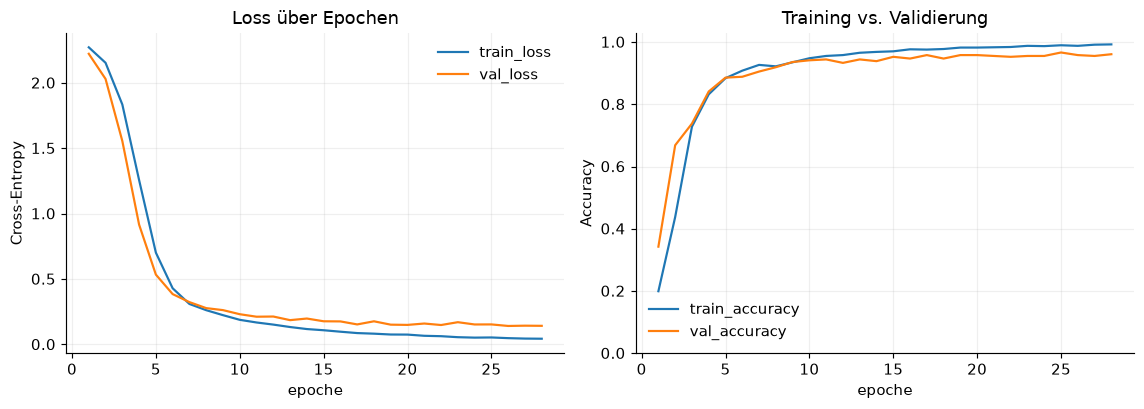

Finaler CNN-Test: {'loss': 0.09629517826769086, 'accuracy': 0.9750000238418579}


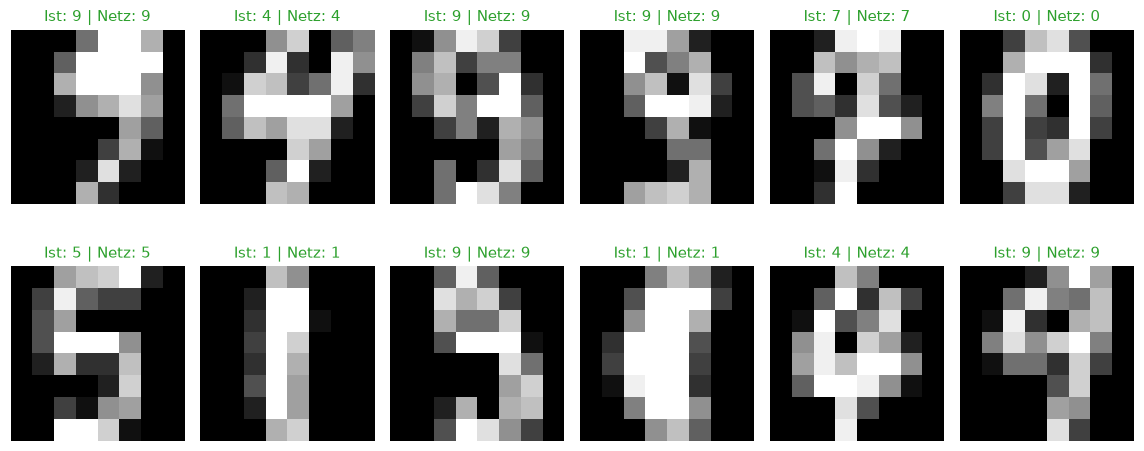

In [5]:
cpu_setup(42)
modell=KleinesCNN()
historie=trainiere(modell,train_loader,val_loader,epochen=28,lr=0.003)
lernkurven(historie)
metriken,probs,y_test=auswerten(modell,test_loader)
print("Finaler CNN-Test:",metriken)
bildgalerie(bilder[split["test"]],y_test,probs)

## 4. Gelernte Filter und ihre Antworten

Wir zeichnen alle acht Filter der ersten Schicht und die zugehörigen **ReLU-Feature-Maps** eines Trainingsbilds. Die Maps verwenden dieselbe Farbskala, damit Aktivierungsstärken vergleichbar bleiben. Filterbilder sind Interpretationshilfen; ein Filter muss nicht für eine einzelne menschlich benennbare Eigenschaft zuständig sein.

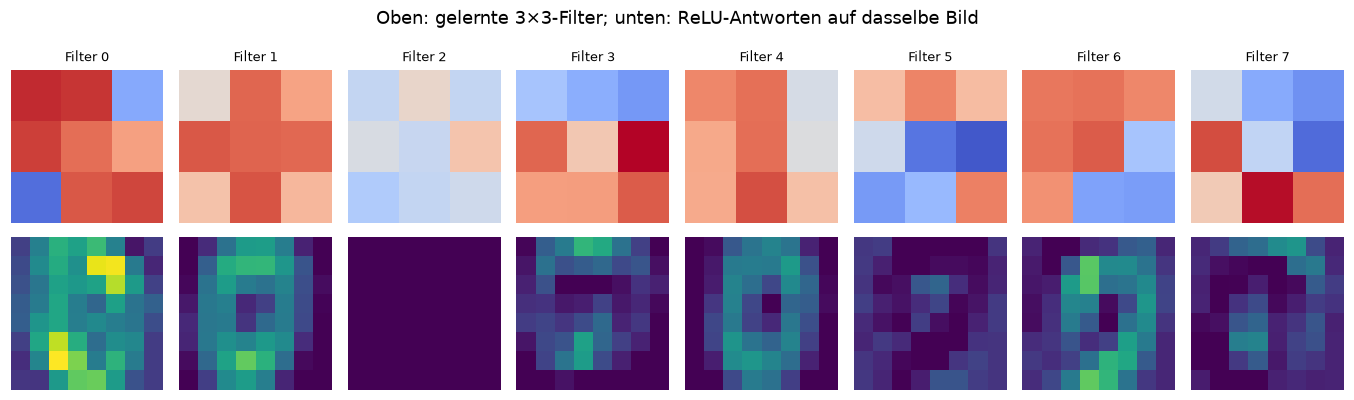

In [6]:
modell.eval()
probe=bilder[split["train"]][0:1]
with torch.inference_mode():maps=modell.features[:2](probe)[0]
kernels=modell.features[0].weight.detach()[:,0]
fig,axes=plt.subplots(2,8,figsize=(13,4))
kmax=float(kernels.abs().max());mmax=float(maps.max())
for i in range(8):
    axes[0,i].imshow(kernels[i],cmap="coolwarm",vmin=-kmax,vmax=kmax)
    axes[0,i].set_title(f"Filter {i}",fontsize=9)
    axes[1,i].imshow(maps[i],cmap="viridis",vmin=0,vmax=mmax)
    for row in range(2):axes[row,i].axis("off")
axes[0,0].set_ylabel("Gewichte");axes[1,0].set_ylabel("Antwort")
fig.suptitle("Oben: gelernte 3×3-Filter; unten: ReLU-Antworten auf dasselbe Bild")
plt.tight_layout();plt.show()

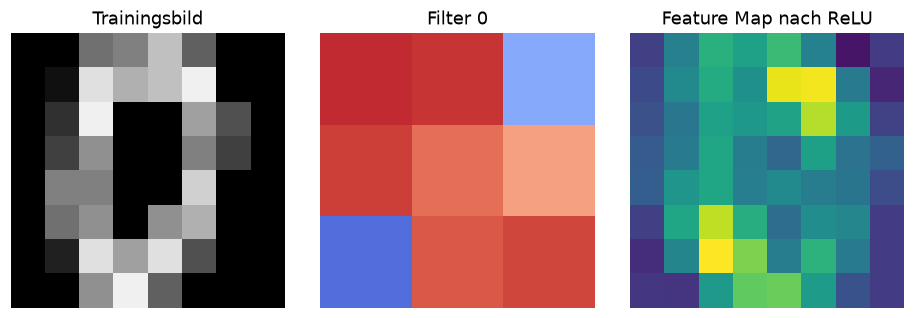

Output()

In [7]:
import ipywidgets as widgets

def zeige_feature_map(bild_index=0,kanal=0):
    probe=bilder[split["train"]][bild_index:bild_index+1]
    with torch.inference_mode():feature=modell.features[:2](probe)[0,kanal]
    fig,axes=plt.subplots(1,3,figsize=(9,3))
    axes[0].imshow(probe[0,0],cmap="gray",vmin=0,vmax=1);axes[0].set_title("Trainingsbild")
    axes[1].imshow(kernels[kanal],cmap="coolwarm",vmin=-kmax,vmax=kmax);axes[1].set_title(f"Filter {kanal}")
    axes[2].imshow(feature,cmap="viridis",vmin=0,vmax=max(mmax,float(feature.max())));axes[2].set_title("Feature Map nach ReLU")
    for ax in axes:ax.axis("off")
    plt.tight_layout();plt.show()
zeige_feature_map()
idx=widgets.IntSlider(value=0,min=0,max=len(split["train"])-1,description="Bild",continuous_update=False)
kanal=widgets.IntSlider(value=0,min=0,max=7,description="Filter",continuous_update=False)
output=widgets.interactive_output(zeige_feature_map,{"bild_index":idx,"kanal":kanal})
display(widgets.VBox([idx,kanal]),output)

## Kleine Aufgaben
1. Berechne die Form nach der ersten Conv ohne Padding.
2. Was geht beim Pooling verloren, was bleibt eher erhalten?
3. Ändere in einer Trainingskopie die erste Kanalzahl auf 4. Wähle Änderungen über die Validierung; wiederholtes Probieren am Test wäre kein fairer Modellvergleich.
4. Worin unterscheiden sich Bildklassifikation und Objekterkennung mit Position/Bounding Box? Dieses Beispiel klassifiziert nur eine bereits ausgeschnittene Ziffer.